In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns

In [2]:
torch.manual_seed(42)
np.random.seed(42)

In [3]:
img_shape = (1, 28, 28)
latent_dim = 20
batch_size = 128
epochs = 30

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

In [6]:
full_train = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
full_test = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

In [7]:
train_loader = DataLoader(full_train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(full_test, batch_size=batch_size, shuffle=False)

In [8]:
print(f"Train size: {len(full_train)}")
print(f"Test size: {len(full_test)}")
print(f"Image shape: {img_shape}")
print(f"Data type: {full_train[0][0].dtype}")

Train size: 60000
Test size: 10000
Image shape: (1, 28, 28)
Data type: torch.float32


In [9]:
def show_grid(images, title="Sample images", nrow=8):
    plt.figure(figsize=(10, 10))
    # images: список тензоров [C,H,W] или батч [B,C,H,W]
    if isinstance(images, torch.Tensor) and images.dim() == 4:
        img_grid = torchvision.utils.make_grid(images[:nrow*nrow], nrow=nrow, normalize=True)
    else:
        img_grid = torchvision.utils.make_grid(images, nrow=nrow, normalize=True)
    plt.imshow(img_grid.permute(1,2,0))
    plt.title(title)
    plt.axis('off')
    plt.show()

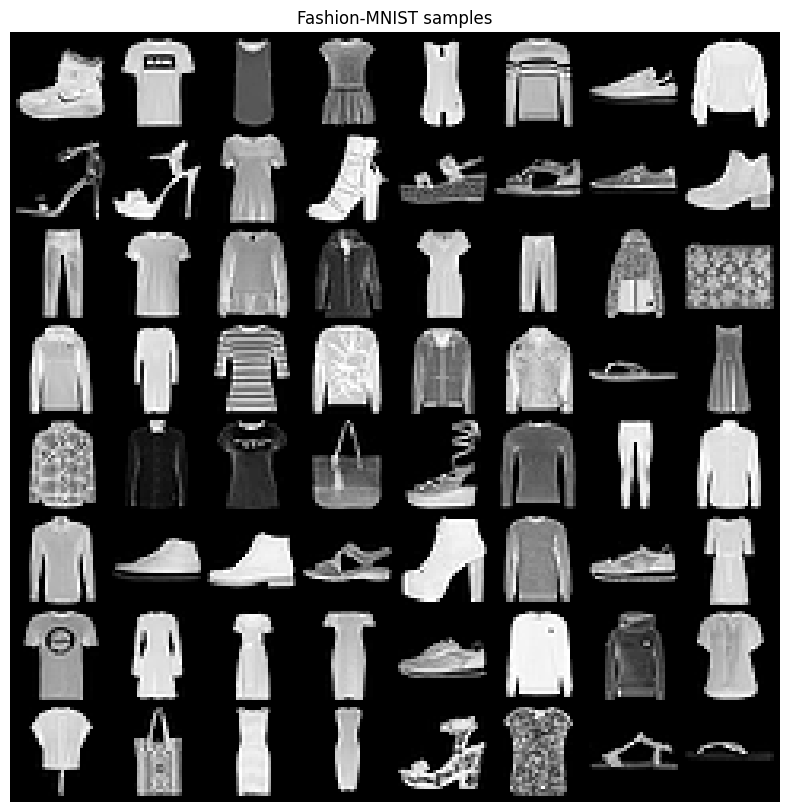

In [10]:
sample_imgs = [full_train[i][0] for i in range(64)]
show_grid(sample_imgs, "Fashion-MNIST samples")

# 2.VAE architecture

In [11]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # 28->14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 14->7
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 7->3
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        self.decoder_input = nn.Linear(latent_dim, 256)
        self.decoder = nn.Sequential(
            nn.Linear(256, 128 * 3 * 3),
            nn.ReLU(),
            nn.Unflatten(1, (128, 3, 3)),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, output_padding=1), # 3->7 (fixed)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 7->14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),   # 14->28
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [12]:
model = VAE(latent_dim=latent_dim).to(device)
print(model)
print(f"Latent dimension: {latent_dim}")
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params}")

VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=1152, out_features=256, bias=True)
    (8): ReLU()
  )
  (fc_mu): Linear(in_features=256, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=20, bias=True)
  (decoder_input): Linear(in_features=20, out_features=256, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=256, out_features=1152, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(128, 3, 3))
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): ReLU()
    (5): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
   

# 3.Reconstruction and KL divergence losses

In [13]:
def vae_loss(recon, x, mu, logvar, beta=1.0):
    #(бинарная кросс-энтропия, т.к. значения в [0,1])
    recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction='sum')
    # KL divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    total = recon_loss + beta * kl_loss
    return total, recon_loss, kl_loss

# 4.VAE training

In [14]:
def train_vae(model, train_loader, test_loader, epochs, beta=1.0, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses = {'total': [], 'recon': [], 'kl': []}
    test_losses = {'total': [], 'recon': [], 'kl': []}

    for epoch in range(epochs):
        model.train()
        train_total, train_recon, train_kl = 0, 0, 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model(data)
            loss, recon_loss, kl_loss = vae_loss(recon, data, mu, logvar, beta)
            loss.backward()
            optimizer.step()
            train_total += loss.item()
            train_recon += recon_loss.item()
            train_kl += kl_loss.item()

        n_train = len(train_loader.dataset)
        train_losses['total'].append(train_total / n_train)
        train_losses['recon'].append(train_recon / n_train)
        train_losses['kl'].append(train_kl / n_train)

        # Оценка на тесте
        model.eval()
        test_total, test_recon, test_kl = 0, 0, 0
        with torch.no_grad():
            for data, _ in test_loader:
                data = data.to(device)
                recon, mu, logvar = model(data)
                loss, recon_loss, kl_loss = vae_loss(recon, data, mu, logvar, beta)
                test_total += loss.item()
                test_recon += recon_loss.item()
                test_kl += kl_loss.item()
        n_test = len(test_loader.dataset)
        test_losses['total'].append(test_total / n_test)
        test_losses['recon'].append(test_recon / n_test)
        test_losses['kl'].append(test_kl / n_test)

        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1:3d} | Train: total {train_losses['total'][-1]:.3f} "
                  f"(recon {train_losses['recon'][-1]:.3f}, kl {train_losses['kl'][-1]:.3f}) | "
                  f"Test: total {test_losses['total'][-1]:.3f} (recon {test_losses['recon'][-1]:.3f}, kl {test_losses['kl'][-1]:.3f})")
    return train_losses, test_losses

In [15]:
train_losses, test_losses = train_vae(model, train_loader, test_loader, epochs, beta=1.0)

Epoch   5 | Train: total 242.379 (recon 230.578, kl 11.801) | Test: total 243.749 (recon 231.721, kl 12.028)
Epoch  10 | Train: total 239.384 (recon 227.258, kl 12.126) | Test: total 241.210 (recon 229.389, kl 11.820)
Epoch  15 | Train: total 238.261 (recon 226.048, kl 12.213) | Test: total 240.339 (recon 228.098, kl 12.241)
Epoch  20 | Train: total 237.513 (recon 225.207, kl 12.306) | Test: total 239.425 (recon 227.159, kl 12.266)
Epoch  25 | Train: total 236.979 (recon 224.618, kl 12.361) | Test: total 239.098 (recon 226.880, kl 12.218)
Epoch  30 | Train: total 236.434 (recon 223.821, kl 12.613) | Test: total 238.848 (recon 226.293, kl 12.555)


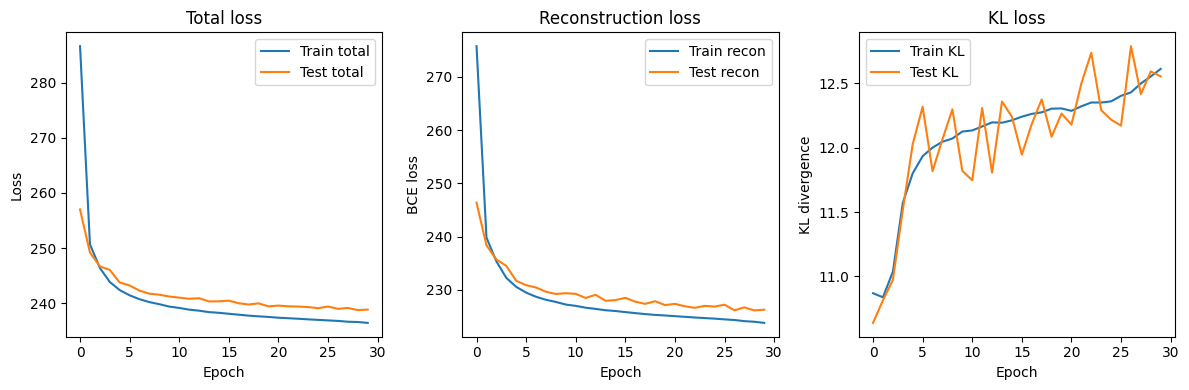

In [16]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(train_losses['total'], label='Train total')
plt.plot(test_losses['total'], label='Test total')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Total loss')

plt.subplot(1,3,2)
plt.plot(train_losses['recon'], label='Train recon')
plt.plot(test_losses['recon'], label='Test recon')
plt.xlabel('Epoch')
plt.ylabel('BCE loss')
plt.legend()
plt.title('Reconstruction loss')

plt.subplot(1,3,3)
plt.plot(train_losses['kl'], label='Train KL')
plt.plot(test_losses['kl'], label='Test KL')
plt.xlabel('Epoch')
plt.ylabel('KL divergence')
plt.legend()
plt.title('KL loss')
plt.tight_layout()
plt.show()

In [17]:
print(f"Final test losses: total={test_losses['total'][-1]:.4f}, "
      f"recon={test_losses['recon'][-1]:.4f}, kl={test_losses['kl'][-1]:.4f}")

Final test losses: total=238.8480, recon=226.2932, kl=12.5548


# 5.Reconstruction quality evaluation

In [18]:
#стандартный АЕ для сравнения
class AE(nn.Module):
    def __init__(self, latent_dim=20):
        super(AE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128*3*3, 256), nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 128*3*3), nn.ReLU(),
            nn.Unflatten(1, (128,3,3)),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Sigmoid()
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [19]:
def train_ae(model, train_loader, epochs=30):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for data, _ in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            recon = model(data)
            loss = nn.functional.mse_loss(recon, data, reduction='sum')
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch+1)%10==0:
            print(f"AE Epoch {epoch+1}, loss: {total_loss/len(train_loader.dataset):.4f}")

In [20]:
ae = AE(latent_dim).to(device)
train_ae(ae, train_loader, epochs=30)

AE Epoch 10, loss: 7.6693
AE Epoch 20, loss: 6.3638
AE Epoch 30, loss: 5.9431


In [21]:
def show_reconstructions(model, loader, title="Reconstructions"):
    model.eval()
    data, _ = next(iter(loader))
    data = data.to(device)
    with torch.no_grad():
        recon, _, _ = model(data) if isinstance(model, VAE) else (model(data), None, None)
    # Покажем первые 16
    n = 16
    original = data[:n].cpu()
    reconstructed = recon[:n].cpu()
    comparison = torch.cat([original, reconstructed], dim=0)
    show_grid(comparison, title=title, nrow=n)

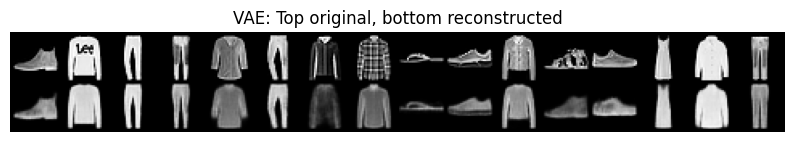

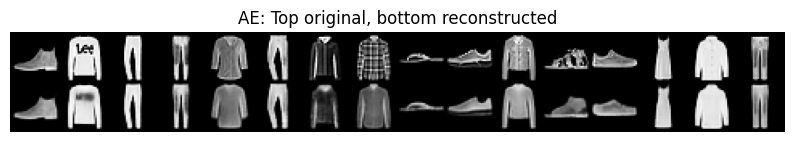

In [22]:
show_reconstructions(model, test_loader, "VAE: Top original, bottom reconstructed")
show_reconstructions(ae, test_loader, "AE: Top original, bottom reconstructed")

In [23]:
def avg_recon_loss(model, loader, loss_fn=nn.functional.mse_loss):
    model.eval()
    total = 0
    with torch.no_grad():
        for data, _ in loader:
            data = data.to(device)
            if isinstance(model, VAE):
                recon, _, _ = model(data)
            else:
                recon = model(data)
            total += loss_fn(recon, data, reduction='sum').item()
    return total / len(loader.dataset)

In [24]:
print(f"VAE average recon loss (MSE): {avg_recon_loss(model, test_loader):.4f}")
print(f"AE average recon loss (MSE): {avg_recon_loss(ae, test_loader):.4f}")

VAE average recon loss (MSE): 12.2342
AE average recon loss (MSE): 6.3531


# 6.. Latent space visualization

In [25]:
def get_latent_vectors(model, loader):
    model.eval()
    z_list = []
    labels_list = []
    with torch.no_grad():
        for data, labels in loader:
            data = data.to(device)
            mu, _ = model.encode(data)
            z_list.append(mu.cpu())
            labels_list.append(labels)
    z = torch.cat(z_list, dim=0).numpy()
    labels = torch.cat(labels_list, dim=0).numpy()
    return z, labels

In [26]:
z_vae, y_vae = get_latent_vectors(model, test_loader)

In [27]:
# PCA
pca = PCA(n_components=2)
z_pca = pca.fit_transform(z_vae)

Text(0.5, 1.0, 'VAE latent space (PCA)')

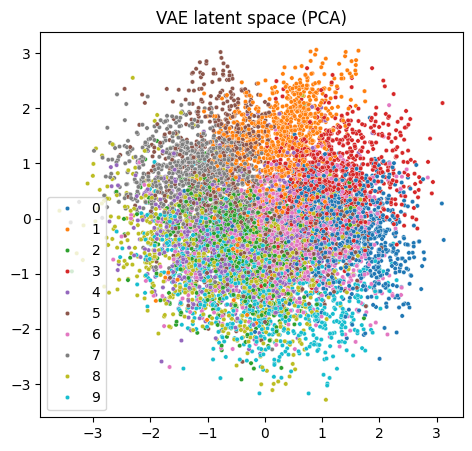

In [28]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x=z_pca[:,0], y=z_pca[:,1], hue=y_vae, palette='tab10', legend='full', s=10)
plt.title("VAE latent space (PCA)")

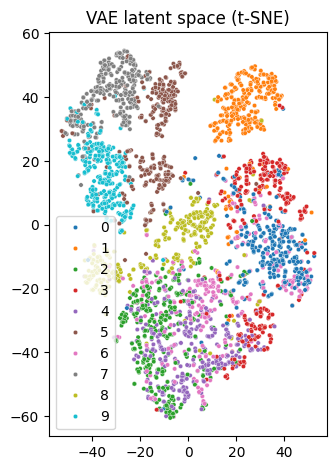

In [29]:
# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
z_tsne = tsne.fit_transform(z_vae[:3000])  # t-SNE на подвыборке для скорости
plt.subplot(1,2,2)
sns.scatterplot(x=z_tsne[:,0], y=z_tsne[:,1], hue=y_vae[:3000], palette='tab10', legend='full', s=10)
plt.title("VAE latent space (t-SNE)")
plt.tight_layout()
plt.show()

In [30]:
class AEWithEncoder(AE):
    def encode(self, x):
        return self.encoder(x), None

ae_enc = AEWithEncoder(latent_dim).to(device)
ae_enc.load_state_dict(ae.state_dict())

z_ae, _ = get_latent_vectors(ae_enc, test_loader)

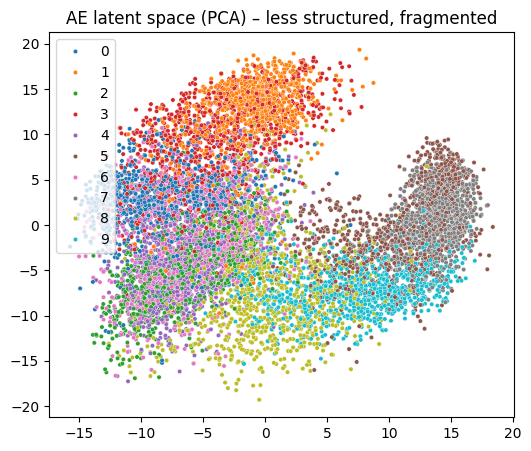

In [31]:
z_ae_pca = PCA(n_components=2).fit_transform(z_ae)
plt.figure(figsize=(6,5))
sns.scatterplot(x=z_ae_pca[:,0], y=z_ae_pca[:,1], hue=y_vae, palette='tab10', s=10)
plt.title("AE latent space (PCA) – less structured, fragmented")
plt.show()

# 7.Sampling and image generation

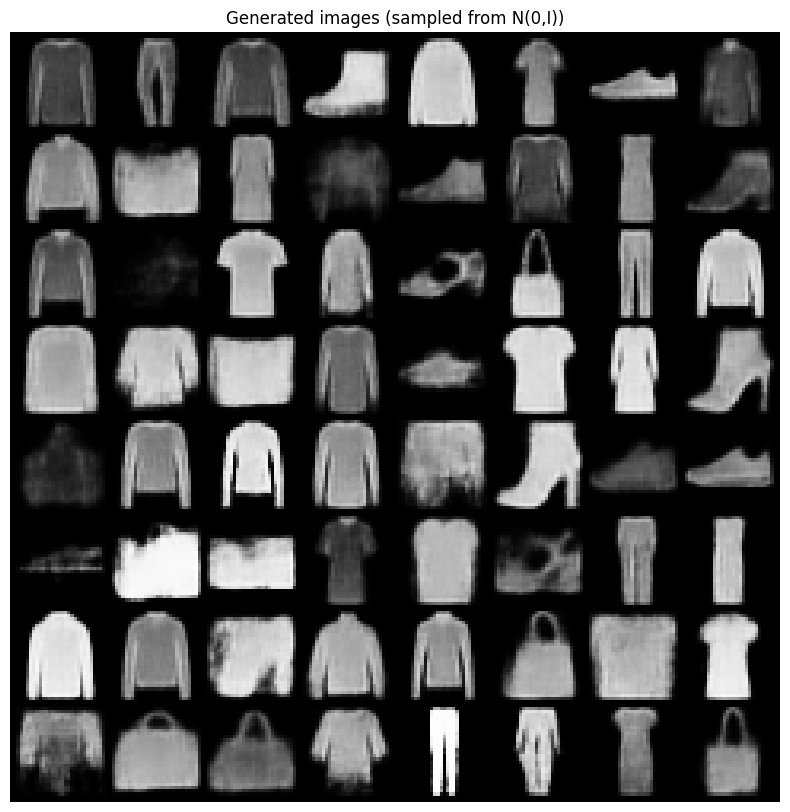

In [32]:
def generate_images(model, n=64):
    model.eval()
    z = torch.randn(n, latent_dim).to(device)
    with torch.no_grad():
        gen = model.decode(z).cpu()
    show_grid(gen, title=f"Generated images (sampled from N(0,I))", nrow=8)

generate_images(model)

# 8.Latent space interpolation

In [33]:
def interpolate(model, img1, img2, label1=None, label2=None, steps=10):
    model.eval()
    with torch.no_grad():
        z1, _ = model.encode(img1.unsqueeze(0).to(device))
        z2, _ = model.encode(img2.unsqueeze(0).to(device))
    alphas = np.linspace(0, 1, steps)
    interp_imgs = []
    for alpha in alphas:
        z = (1-alpha)*z1 + alpha*z2
        with torch.no_grad():
            img = model.decode(z).cpu()
        interp_imgs.append(img.squeeze(0))

    grid = torch.stack(interp_imgs, dim=0)
    title = f"Interpolation from {label1} to {label2}" if label1 is not None else "Interpolation"
    show_grid(grid, title=title, nrow=steps)

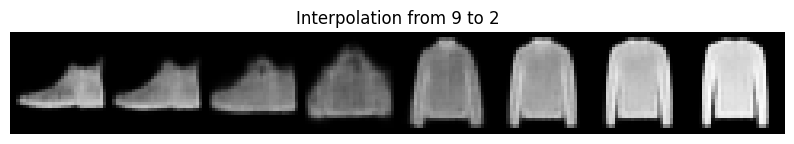

In [34]:
test_iter = iter(test_loader)
imgs, labels = next(test_iter)
img_a, label_a = imgs[0], labels[0]
img_b, label_b = imgs[1], labels[1]

interpolate(model, img_a, img_b, label1=label_a.item(), label2=label_b.item(), steps=8)

# 9. Effect of KL weight

In [35]:
betas = [0.2, 1.0, 3.0]
models_beta = {}
losses_beta = {}

for beta in betas:
    print(f"Training with beta = {beta}")
    model_beta = VAE(latent_dim=latent_dim).to(device)
    train_loss, test_loss = train_vae(model_beta, train_loader, test_loader, epochs=20, beta=beta)
    models_beta[beta] = model_beta
    losses_beta[beta] = test_loss

Training with beta = 0.2
Epoch   5 | Train: total 226.659 (recon 221.325, kl 26.672) | Test: total 227.520 (recon 222.181, kl 26.692)
Epoch  10 | Train: total 221.886 (recon 216.317, kl 27.841) | Test: total 223.578 (recon 218.062, kl 27.579)
Epoch  15 | Train: total 220.138 (recon 214.531, kl 28.036) | Test: total 222.038 (recon 216.328, kl 28.549)
Epoch  20 | Train: total 219.304 (recon 213.680, kl 28.120) | Test: total 221.715 (recon 216.155, kl 27.798)
Training with beta = 1.0
Epoch   5 | Train: total 242.376 (recon 230.499, kl 11.877) | Test: total 243.481 (recon 231.081, kl 12.400)
Epoch  10 | Train: total 239.441 (recon 227.225, kl 12.216) | Test: total 241.389 (recon 229.435, kl 11.955)
Epoch  15 | Train: total 238.311 (recon 225.969, kl 12.342) | Test: total 239.945 (recon 227.820, kl 12.125)
Epoch  20 | Train: total 237.563 (recon 225.139, kl 12.424) | Test: total 239.743 (recon 227.406, kl 12.338)
Training with beta = 3.0
Epoch   5 | Train: total 262.738 (recon 242.306, kl 6

Beta=0.2: Final test recon loss = 216.1553, KL = 27.7982


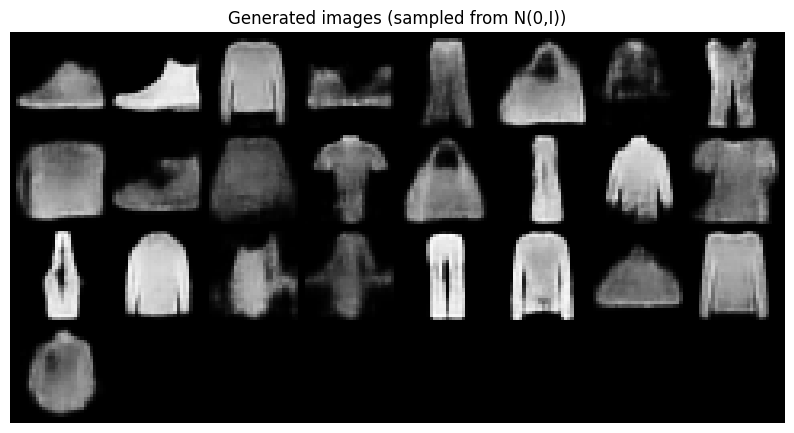

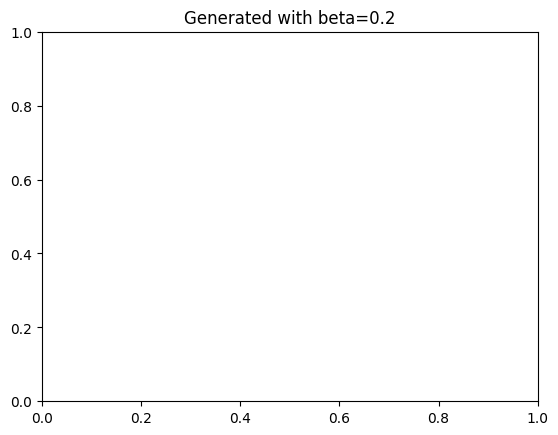

Beta=1.0: Final test recon loss = 227.4057, KL = 12.3377


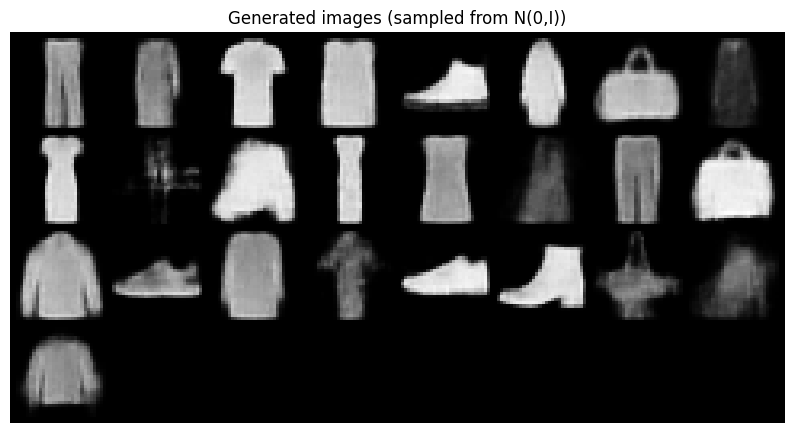

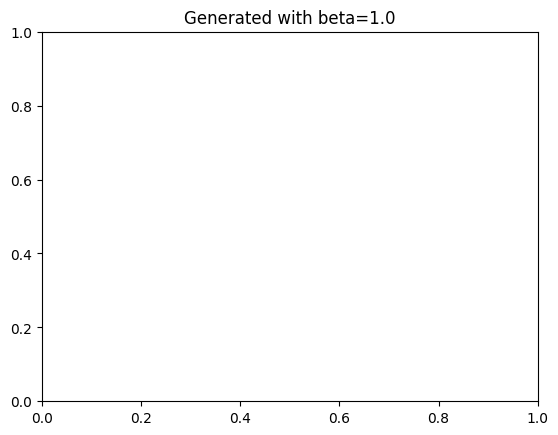

Beta=3.0: Final test recon loss = 237.0719, KL = 7.6305


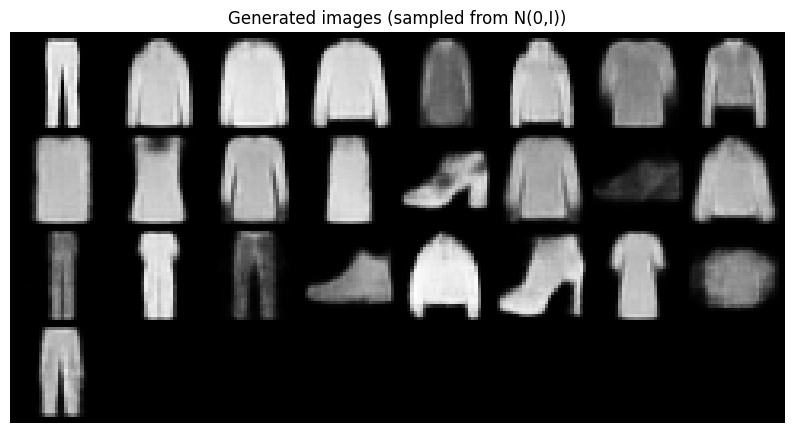

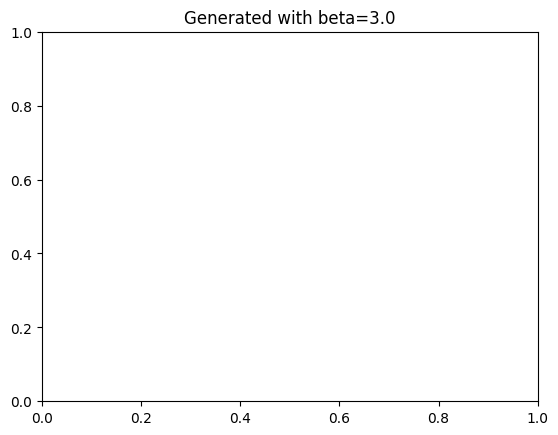

In [36]:
for beta in betas:
    print(f"Beta={beta}: Final test recon loss = {losses_beta[beta]['recon'][-1]:.4f}, KL = {losses_beta[beta]['kl'][-1]:.4f}")
    generate_images(models_beta[beta], n=25)
    plt.title(f"Generated with beta={beta}")
    plt.show()